In [1]:
import numpy as np
from scipy import signal
import tensorflow as tf
from tensorflow.keras import layers, Model, initializers, Sequential
from optic.models.devices import mzm, photodiode, edfa, iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel
from optic.models.channels import linearFiberChannel, ssfm
from optic.comm.modulation import modulateGray, grayMapping
from optic.comm.sources import bitSource, symbolSource
from optic.dsp.core import upsample, pulseShape, pnorm, anorm, signalPower, firFilter, decimate, symbolSync,phaseNoise

try:
    from optic.dsp.coreGPU import checkGPU
    if checkGPU():
        from optic.dsp.coreGPU import firFilter
    else:
        from optic.dsp.core import firFilter
except ImportError:
    from optic.dsp.core import firFilter

from optic.utils import parameters, dBm2W, ber2Qfactor
from optic.plot import eyediagram, pconst, plotPSD
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm.notebook import tqdm
import scipy as sp
import scipy.constants as const

try:
    from optic.models.modelsGPU import manakovSSF
except:
    from optic.models.channels import manakovSSF

from optic.dsp.equalization import edc, mimoAdaptEqualizer, ffe
from optic.dsp.carrierRecovery import cpr
from optic.comm.metrics import fastBERcalc, monteCarloGMI, monteCarloMI, calcEVM, bert
from optic.dsp.clockRecovery import gardnerClockRecovery


import logging as logg
logg.basicConfig(level=logg.INFO, format='%(message)s', force=True)
import time

I0000 00:00:1774952253.602141 3280004 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774952253.756645 3280004 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774952255.670448 3280004 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
from IPython.core.display import HTML
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [3]:
# --------------------------------------------------------------------------------------------------------------------------------------
# Power Amplifier (PA) Functions
# ---------------------------------------------------------------------------------------------------------------------------------------

def rapp_pa(x, Vsat, p=2.0):
    """
    Memoryless Rapp PA model for complex baseband input.

    Parameters
    ----------
    x : np.ndarray
        Complex input waveform in volts.
    Vsat : float
        Saturation voltage/amplitude.
    p : float
        Rapp smoothness exponent.

    Returns
    -------
    y : np.ndarray
        Output after memoryless PA nonlinearity.
    """
    mag = np.abs(x)
    gain = 1.0 / (1.0 + (mag / Vsat) ** (2 * p)) ** (1.0 / (2 * p))
    return x * gain


def butter_lpf_complex(x, Fs, f3dB, order=3):
    """
    Apply an order-N Butterworth LPF to a complex baseband waveform.
    """
    wn = f3dB / (Fs / 2)

    if wn >= 1.0:
        raise ValueError(
            f"Butterworth cutoff must be below Nyquist. Got f3dB={f3dB/1e9:.2f} GHz, "
            f"Fs/2={(Fs/2)/1e9:.2f} GHz."
        )

    b, a = signal.butter(order, wn, btype='low')

    y_i = signal.lfilter(b, a, np.real(x))
    y_q = signal.lfilter(b, a, np.imag(x))

    return y_i + 1j * y_q


def pa_model_physical(x, Fs, gain_linear, BLPF_enable, BO_dB=5.0, p=2.0, f3dB=10e9, order=3):
    """
    Physical PA model:
        x -> linear gain -> Rapp compression -> Butterworth LPF

    Parameters
    ----------
    x : np.ndarray
        Complex baseband input waveform (dimensionless DSP waveform).
    Fs : float
        Sample rate [Hz].
    gain_linear : float
        Small-signal linear voltage gain. This sets the nominal IQM drive level.
    BO_dB : float
        Back-off in dB, used to set Vsat relative to the RMS value AFTER gain.
    p : float
        Rapp exponent.
    f3dB : float
        PA 3-dB bandwidth [Hz].
    order : int
        Butterworth filter order.

    Returns
    -------
    y : np.ndarray
        PA output waveform in volts, ready to drive the IQM.
    info : dict
        Diagnostic information.
    """

    # 1) Linear gain stage -> now waveform is in volts
    x_amp = gain_linear * x

    # 2) Compute RMS after gain
    Vrms_in = np.sqrt(np.mean(np.abs(x_amp) ** 2))

    # 3) Saturation voltage from back-off
    Vsat = Vrms_in * 10 ** (BO_dB / 20)

    # 4) Nonlinear compression
    y_nl = rapp_pa(x_amp, Vsat=Vsat, p=p)

    # 5) PA bandwidth limitation
    if BLPF_enable:
        y = butter_lpf_complex(y_nl, Fs=Fs, f3dB=f3dB, order=order)
    else:
        y = y_nl

    info = {
        "gain_linear": gain_linear,
        "Vrms_in_V": Vrms_in,
        "Vsat_V": Vsat,
        "BO_dB": BO_dB,
        "p": p,
        "f3dB_Hz": f3dB,
        "peak_out_V": np.max(np.abs(y)),
        "rms_out_V": np.sqrt(np.mean(np.abs(y) ** 2)),
    }

    return y, info

In [4]:
def select_cpr_mode(paramCPR_, CPR_Mode, Ts, M):
    paramCPR = paramCPR_
    paramCPR.Ts = Ts
    paramCPR.M  = M
    paramCPR.returnPhases = True

    if CPR_Mode.lower() == "bps":
        paramCPR.alg = "bps"
        if M == 16:
            paramCPR.N = 25
            paramCPR.B = 64
        elif M == 32:
            paramCPR.N = 31
            paramCPR.B = 128
        elif M == 64:
            #paramCPR.N = 81
            paramCPR.N = 101
            paramCPR.B = 2048
            #paramCPR.B = 1024
        elif M == 256:
            paramCPR.N = 81
            paramCPR.B = 512

    elif CPR_Mode.lower() == "ddpll":
        paramCPR.alg = "ddpll"
        if M == 16:
            # recommended DDPLL parameters
            paramCPR.tau1 = 1/(2*np.pi*10e3)
            paramCPR.tau2 = 1/(2*np.pi*10e3)
            paramCPR.Kv   = 0.1
        elif M == 32:
            paramCPR.tau1 = 1/(2*np.pi*20e3)
            paramCPR.tau2 = 1/(2*np.pi*20e3)
            paramCPR.Kv   = 0.1
            
        elif M == 64:
            #paramCPR.tau1 = 1/(2*np.pi*30e3)
            #paramCPR.tau2 = 1/(2*np.pi*30e3)
            #paramCPR.Kv   = 0.15
            paramCPR.Kv = 0.07
            paramCPR.tau1 = 1/(2*np.pi*5e6)
            paramCPR.tau2 = 1/(2*np.pi*5e6)
        elif M == 256:
            paramCPR.tau1 = 1/(2*np.pi*40e3)
            paramCPR.tau2 = 1/(2*np.pi*40e3)
            paramCPR.Kv   = 0.12  # faster tracking needed
          
    else:
        raise ValueError("CPR_Mode must be 'bps' or 'ddpll'")

    return paramCPR

In [5]:
def select_equalizer_mode(M, Data_Aided, paramEq_):
    """
    Selects the equalizer algorithm and step sizes 
    based on M, Data_Aided flag, and chosen mode.
    """
    paramEq = paramEq_
    if Data_Aided:
        if M == 4:
            # For QPSK
            paramEq.alg = ['cma', 'cma']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 2
        elif M == 16:
            # For 16-QAM
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [5e-3, 5e-4]
            paramEq.numIter = 3
        elif M == 32:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 4
            paramEq.nTaps = 45
        elif M == 64:
            paramEq.alg = ['da-rde', 'rde']
            paramEq.mu  = [8e-4, 4e-4]
            paramEq.mu  = [8e-4, 3e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 65
            #paramEq.alg = ['da-rde', 'cma']
            #paramEq.mu = [3e-4, 5e-5]
            #paramEq.numIter = 4
            #paramEq.nTaps = 85
        elif M == 256:
            paramEq.alg = ['da-rde', 'da-rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 180
            
            
    else:  # Blind mode
        if M == 4:
            paramEq.alg = ['cma','cma']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 2
        elif M == 16:
            paramEq.alg = ['cma','rde']
            paramEq.mu  = [5e-3, 1e-3]
            paramEq.numIter = 3
        elif M == 32:
            paramEq.alg = ['cma','rde']
            paramEq.mu  = [2e-3, 5e-4]
            paramEq.numIter = 4
            paramEq.nTaps = 45
        elif M == 64:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [1e-3, 1e-3]
            paramEq.numIter = 5
            paramEq.nTaps = 55
        elif M == 256:
            paramEq.alg = ['cma', 'rde']
            paramEq.mu  = [5e-4, 5e-4]
            paramEq.numIter = 6
            paramEq.nTaps = 65
   
            
    return paramEq

In [28]:
def perf_calc(symbTx, y_CPR_1, d_, M, paramSymb):
    """Performance Metric Exploration for Single Polarization"""
    d = d_
    discard = 5000
    ind = np.arange(discard, len(symbTx) - discard)
    
    # Remove phase ambiguity for all M (optional: for QAM)
    if M in [4, 16, 32, 64, 128]:
        d = symbTx  # or processed reference symbols

    # Compute metrics
    BER, SER, SNR = fastBERcalc(y_CPR_1[ind], d[ind], M, 'qam', px=paramSymb.px)
    EVM = calcEVM(y_CPR_1[ind], M, 'qam', d[ind])
    Qfactor = ber2Qfactor(BER[0])

    print(' SER: %.3e,  '%(SER[0]))
    print(' BER: %.3e   '%(BER[0]))
    print(' SNR: %.3f dB'%(SNR[0]))
    print(' EVM: %.3f %%'%(EVM[0]*100))
    print(' Qfactor: %.3f,  '%(Qfactor))

    #return BER[0], SER[0], SNR[0], EVM[0], Qfactor
    return BER[0]

In [29]:
# ----------------------------------------------
# Simulation of the Optical System (parametric version)
# -----------------------------------------------

def simulate_optical_system(
    symbTx,
    no_symbols_sent,
    M,
    PA_enable=True,
    Data_Aided=True,
    SpS=16,
    SpSout=2,
    Fs=None,
    mzmScale=0.5,
    Vpi=2,
    BLPF_enable=True,
    PA_BO_dB=3,
    PA_p=2.0,
    PA_f3dB=18.5e9,
    P_launch_dBm=0,
    Rs = 32e9,                
    rollOff = 0.01,           
    nFilterTaps = 1024,       
    laserLinewidth = 100e3, 
    FO  = -128e6,
    CPR_Mode = "bps",
    pulse_type="rrc",
    ch_Ltotal_km=80,
    ch_Lspan_km=80,
    ch_alpha_dB_per_km=0.2,
    ch_D_ps_nm_km=16,
    ch_gamma=1.3,
    ch_Fc=193.1e12,
    ch_hz_km=0.5,
    ch_prgsBar=True,
    ch_amp="edfa",
    ch_NF_dB=4.5,
    lo_P_dBm=2,
    lo_RIN_var=0,
    lo_freq_shift_base_hz=0,
    pn_tx_seed=123,
    lo_rx_seed=789,
    pd_seed=1011,
    pd_ideal=True,
    edc_Fs=None,
    pa_order=3,
    ):                
    
    # (derived) params
    if Fs is None:
        Fs = Rs * SpS
    # 3) UpSampling and FIR Parameters
    paramPulse = parameters()
    paramPulse.pulseType = pulse_type
    paramPulse.nFilterTaps = nFilterTaps
    paramPulse.rollOff = rollOff
    paramPulse.SpS = SpS

    # 4) IQM Parameters
    paramIQM = parameters()
    paramIQM.Vpi = Vpi
    paramIQM.VbI = -Vpi
    paramIQM.VbQ = -Vpi
    paramIQM.Vphi = Vpi/2

    # 5) Optical Carrier / LO field (Ein)
    sigTx_length = no_symbols_sent * SpS
    if laserLinewidth and laserLinewidth > 0:
        phi_pn = phaseNoise(laserLinewidth, sigTx_length, 1 / Fs, seed=pn_tx_seed)
        sigLO = np.exp(1j * phi_pn)
    else:
        sigLO = np.ones_like(sigTx_length, dtype=complex)


    # -----------------------------------------------
    # Channel Parameters
    #------------------------------------------------

    # 1) Optical Channel Parameters
    paramCh = parameters()
    paramCh.Ltotal = ch_Ltotal_km
    paramCh.Lspan = ch_Lspan_km
    paramCh.alpha = ch_alpha_dB_per_km
    paramCh.D = ch_D_ps_nm_km
    paramCh.gamma = ch_gamma
    paramCh.Fc = ch_Fc
    paramCh.hz = ch_hz_km
    paramCh.prgsBar = ch_prgsBar
    paramCh.Fs = Fs
    paramCh.amp = ch_amp
    paramCh.NF = ch_NF_dB
    #paramCh.seed = 456


    # -----------------------------------------------
    # Receiver Parameters
    #------------------------------------------------

    # 1) local oscillator (LO) parameters:

    paramLO = parameters()
    paramLO.P = lo_P_dBm
    paramLO.lw = laserLinewidth
    paramLO.RIN_var = lo_RIN_var
    paramLO.Fs = Fs
    paramLO.seed = lo_rx_seed
    paramLO.freqShift = lo_freq_shift_base_hz + FO

    # 2) Front-End Parameters and photodiode paramters

    # Frontend parameters
    paramFE = parameters()
    paramFE.Fs = Fs

    # Photodiodes parameters
    paramPD = parameters()
    paramPD.B = Rs
    paramPD.Fs = Fs
    paramPD.ideal = pd_ideal
    paramPD.seed = pd_seed

    # 3) Pulseshaping in the reciever using rrc filter
    paramRxPulse = parameters()
    paramRxPulse.SpS = SpS
    paramRxPulse.nFilterTaps = nFilterTaps
    paramRxPulse.rollOff = rollOff
    paramRxPulse.pulseType = pulse_type

    # 4) Decimation Parameters
    paramDec = parameters()
    paramDec.SpSin  = SpS
    paramDec.SpSout = SpSout

    # 5) Chromatic Dispersion Parameters
    paramEDC = parameters()
    paramEDC.L = paramCh.Ltotal
    paramEDC.D = paramCh.D
    paramEDC.Fc = paramCh.Fc
    paramEDC.Rs = Rs
    paramEDC.Fs = 2 * Rs if edc_Fs is None else edc_Fs

    # 6) Adaptive Equalization Parameters
    paramEq = parameters()
    paramEq.nTaps = 35
    paramEq.SpS = paramDec.SpSout
    paramEq.numIter = 2
    paramEq.storeCoeff = False
    paramEq.M = M
    paramEq.shapingFactor = 0
    paramEq.constType = "qam"
    paramEq.prgsBar = False

    # 7) Data-Aided or Blind Reciever Equalization
    # Can be set here or not
    #Data_Aided = True

    # 8) Carrier and Phase recovery parameters using bps
    paramCPR = parameters()
    paramCPR.alg = 'bps'
    paramCPR.M   = M
    paramCPR.constType ="qam"
    paramCPR.shapingFactor = 0
    paramCPR.N   = 25
    paramCPR.B   = 64
    paramCPR.returnPhases = True
    paramCPR.Ts = 1/Rs




    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # TRANSMITTER

    # 2) Upsampling + pulse shaping
    pulse = pulseShape(paramPulse)
    symbolsUp = upsample(symbTx, SpS)
    sigTx = firFilter(pulse, symbolsUp)

    # 3) Choose nominal small-signal PA gain so the nominal drive is around mzmScale * Vpi
    target_peak_V = mzmScale * Vpi
    peak_sigTx = np.max(np.abs(sigTx))

    if peak_sigTx == 0:
        raise ValueError("sigTx peak is zero; cannot set PA gain.")

    gain_linear = target_peak_V / peak_sigTx

    # 4) Driver amplifier / PA output directly in volts
    if PA_enable:
        u_drive, paInfo = pa_model_physical(
            sigTx,
            Fs=Fs,
            gain_linear=gain_linear,
            BLPF_enable=BLPF_enable,
            BO_dB=PA_BO_dB,
            p=PA_p,
            f3dB=PA_f3dB,
            order=pa_order,
        )
    else:
        u_drive = gain_linear * sigTx
        paInfo = {
            "gain_linear": gain_linear,
            "Vrms_in_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
            "Vsat_V": None,
            "BO_dB": None,
            "p": None,
            "f3dB_Hz": None,
            "peak_out_V": np.max(np.abs(u_drive)),
            "rms_out_V": np.sqrt(np.mean(np.abs(u_drive) ** 2)),
        }

    # 5) IQ modulation: PA output drives the IQM directly
    sigTxo = iqm(sigLO, u_drive, paramIQM)

    # 6) Set launched optical power
    P_launch_W = dBm2W(P_launch_dBm)
    sigTxo = np.sqrt(P_launch_W) * pnorm(sigTxo)

    # End of Transmitter
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # CHANNEL

    sigCh = ssfm(sigTxo, paramCh)

    # End of CHANNEL
    # -----------------------------------------------------------------------------------------------------------------------------------------------------

    # -----------------------------------------------------------------------------------------------------------------------------------------------------
    # RECEIVER

    # 1) Generate CW laser LO field
    paramLO.Ns = len(sigCh)
    sigLO_Rx = basicLaserModel(paramLO)

    # 2) Coherent receiver for single-polarization
    sigRxFrontEnd = coherentReceiver(sigCh, sigLO_Rx, paramFE, paramPD)

    # 3) Pulse shaping
    pulse = pulseShape(paramRxPulse)
    sigRxPulseShape = firFilter(pulse, sigRxFrontEnd)

    # 4) Decimation
    sigRxDecimation = decimate(sigRxPulseShape, paramDec)

    # 5) Chromatic Dispersion Compensation
    sigRxCD = edc(sigRxDecimation, paramEDC)

    # 6) Symbol Synchronization with the SymbTx
    symbRxCD = symbolSync(sigRxCD, symbTx, 2)

    # 7) Power Normalization
    x = pnorm(sigRxCD)
    d = pnorm(symbRxCD)

    if M==256 and Data_Aided:
        paramEq.L = [int(0.5*d.shape[0]), int(0.5*d.shape[0])]
    else:
        paramEq.L = [int(0.2*d.shape[0]), int(0.8*d.shape[0])]
   
    #paramEq.L         = [int(0.8 * d.shape[0])]    # or d.shape[0] - 20k
    # ------------------------------------------------
    # 5) EQUALIZATION (via DSP SWITCH)
    # ------------------------------------------------
    paramEq = select_equalizer_mode(M, Data_Aided, paramEq)

    if Data_Aided:
        print(" adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, d)
    else:
        print("no adied")
        y_EQ = mimoAdaptEqualizer(x, paramEq, None)

    #y_EQ, h_rls = rls_single_pol(x, d, L=21, lam=0.995, delta=1e3)

    # ------------------------------------------------
    # 6) Frequency Offset Compensation
    # ------------------------------------------------
    Ts = 1 / Rs
    paramCPR = select_cpr_mode(paramCPR, CPR_Mode, Ts, M)
    if CPR_Mode == "ddpll":
        print("no bps")
        
        y_EQ_2D = y_EQ.reshape(-1,1) if y_EQ.ndim == 1 else y_EQ
        
        symbTx_2D = symbTx.reshape(-1,1)
        y_CPR_1, phaseEst = cpr(y_EQ_2D, param=paramCPR, symbTx=symbTx_2D)
        y_CPR_1= y_CPR_1.flatten()
    else:
        print("yes bps")
        y_CPR_1, phaseEst = cpr(y_EQ, paramCPR)

    return y_CPR_1, d, phaseEst


In [30]:
def intialise_paramSymb(M, nBits, seed=444):
    # Symbol generation    
    paramSymb = parameters()
    paramSymb.nSymbols = int(nBits // np.log2(M))  # symbols = bits / log2(M)
    paramSymb.M = M
    paramSymb.constType = "qam"                    # 'qam' with M=4 -> QPSK
    paramSymb.dist = "uniform"                     # uniform symbol probabilities
    paramSymb.seed = 444
    paramSymb.shapingFactor = 0

    constSymb = grayMapping(paramSymb.M, paramSymb.constType)
    if paramSymb.dist == "uniform":
        px = np.ones(paramSymb.M) / paramSymb.M
    elif paramSymb.probDist == "maxwell-boltzmann":
        px = np.exp(-paramSymb.shapingFactor * np.abs(constSymb) ** 2)
        px = px / np.sum(px)
    else:
        raise ValueError("Invalid probability distribution.")
    paramSymb.px = px
    return paramSymb

## System First Trial - No DPD

In [31]:
M = 16
nBits = 400000
SpSout = 2
paramSymb = intialise_paramSymb(M, nBits)


Launch Power Sweep:   0%|          | 0/12 [00:00<?, ?power/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.055704.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.049921.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.049841.
rde - training stage #1


 adied


rde MSE = 0.030639.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...


...

 adied


rde MSE = 0.026765.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...


yes bps


Estimated linewidth: 616.773 kHz


 SER: 5.956e-03,  
 BER: 1.489e-03   
 SNR: 17.651 dB
 EVM: 1.714 %
 Qfactor: 4.728,  


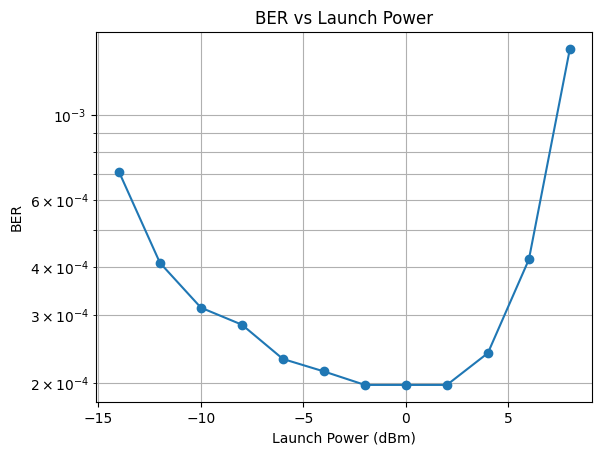

In [33]:
P_launch_dbm_list = [-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8]
ber_list = []

symbTx = symbolSource(paramSymb)


for P_launch in tqdm(P_launch_dbm_list, desc="Launch Power Sweep", unit="power"):

    y_CPR_1, d, phaseEst = simulate_optical_system(symbTx, len(symbTx), M, PA_enable=True, Data_Aided=True, SpSout=SpSout, mzmScale=0.8, P_launch_dBm=P_launch)
    ber = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)

    
    ber_list.append(ber)

plt.figure()
plt.semilogy(P_launch_dbm_list, ber_list, 'o-')
plt.xlabel("Launch Power (dBm)")
plt.ylabel("BER")
plt.grid(True, which="both")
plt.title("BER vs Launch Power")
plt.show()

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0


 adied


da-rde MSE = 0.041902.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.036045.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.035964.
rde - training stage #1
rde MSE = 0.023887.
Running frequency offset compensation...


yes bps


Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...
Estimated linewidth: 389.616 kHz


 SER: 7.889e-04,  
 BER: 1.972e-04   
 SNR: 19.457 dB
 EVM: 1.138 %
 Qfactor: 5.495,  


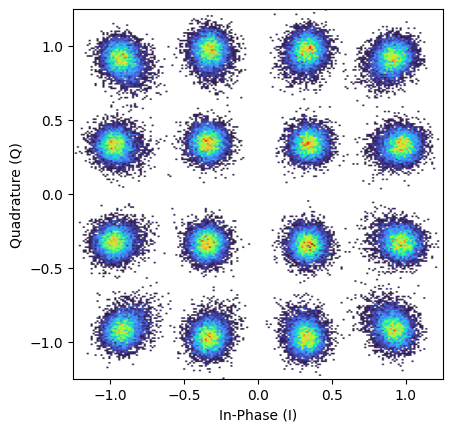

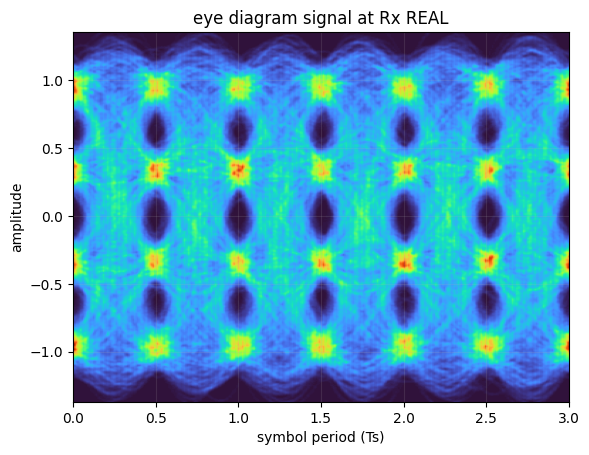

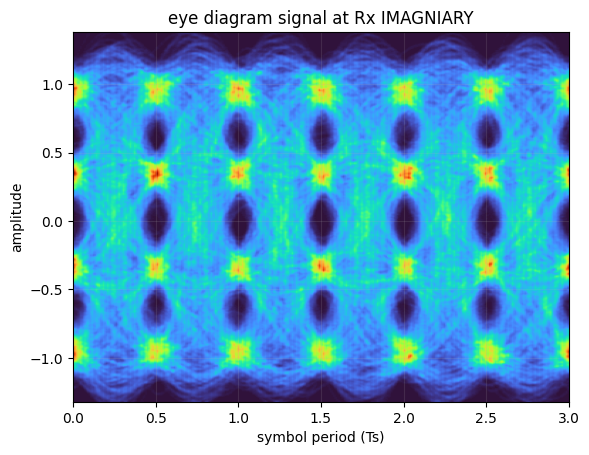

In [10]:
symbTx = symbolSource(paramSymb)


y_CPR_1, d, phaseEst = simulate_optical_system(symbTx, len(symbTx), M, PA_enable=True, Data_Aided=True, SpSout=SpSout, mzmScale=0.8)


perf_calc(symbTx, y_CPR_1, d, M, paramSymb)


discard = 5000
# plot constellations
pconst(y_CPR_1[discard:-discard])

# plotting eye diagrams of sigTx
eyediagram(y_CPR_1.real[discard:-discard], y_CPR_1.real.size-2*discard, SpSout, plotlabel='signal at Rx REAL', ptype='fancy')
eyediagram(y_CPR_1.imag[discard:-discard], y_CPR_1.imag.size-2*discard, SpSout, plotlabel='signal at Rx IMAGNIARY', ptype='fancy')


## System Benchmark (No DPD)

In [ ]:
# results = []

# # modulation orders to test
# mod_orders = [16,64,256]

# # DA and CPR modes
# modes_DataAided = [True, False]
# modes_CPR = [ "bps","ddpll"]

# for M_test in mod_orders:
#     M = M_test
#     paramSymb = intialise_paramSymb(M, nBits) # need to update it everytime M changes
#     for da in modes_DataAided:
#         for cpr_mode in modes_CPR:
#             print("\n===================================================")
#             print(f" Running:  M={M}, Data_Aided={da}, CPR_Mode={cpr_mode}")
#             print("===================================================\n")
        
#             # fresh symbol stream each run
#             symbTx = symbolSource(paramSymb)
            
#             # run sys
#             y_CPR_1, d, phaseEst = simulate_optical_system(symbTx, len(symbTx), M, 
#                                                            Data_Aided=da, 
#                                                            SpSout=SpSout,
#                                                            CPR_Mode=cpr_mode)

#             discard = 5000

#             # optional: plot constellations
#             pconst(y_CPR_1[discard:-discard])

#             # plotting eye diagrams
#             eyediagram(y_CPR_1.real[discard:-discard],
#                         y_CPR_1.real.size-2*discard,
#                         SpSout,
#                         plotlabel=f'signal at Rx REAL, M={M}', ptype='fancy')
#             eyediagram(y_CPR_1.imag[discard:-discard],
#                         y_CPR_1.imag.size-2*discard,
#                         SpSout,
#                         plotlabel=f'signal at Rx IMAGINARY, M={M}', ptype='fancy')


#             # performance
#             BER, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)


#             results.append({
#                 "Modulation": M,
#                 "Data_Aided": da,
#                 "CPR": cpr_mode,
#                 "BER": BER,
#                 "SER": SER,
#                 "SNR": SNR,
#                 "EVM": EVM,
#                 "Qfactor": Q
#             })


In [ ]:
# print("\n==================== SUMMARY TABLE ====================\n")
# for r in results:
#     print(f"DA={r['Data_Aided']}, CPR={r['CPR']}: "
#           f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
#           f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")

# DPD

In [36]:
def build_model():
    inputs = layers.Input(shape=(None, 2)) # 2 for I and Q

    sec_a = layers.Conv1D(2, 100, padding='same')(inputs) # 100 taps was a sweet spot, 20-ish fails to converge, tiker with different values.

#    sec_a = inputs

    # nonlinear_1 = layers.Dense(20, activation=layers.LeakyReLU(0.1))(sec_a)
    # nonlinear_2 = layers.Dense(20, activation=layers.LeakyReLU(0.1))(nonlinear_1)
    # nonlinear_3 = layers.Dense(2, activation=layers.LeakyReLU(0.1))(nonlinear_2)
    # nonlinear_4 = layers.Dense(2, activation='linear')(nonlinear_3)
    

    nonlinear_1 = layers.Dense(20, activation=tf.math.sin)(sec_a)
    nonlinear_2 = layers.Dense(20, activation=tf.math.sin)(nonlinear_1)
    nonlinear_3 = layers.Dense(2, activation=tf.math.sin)(nonlinear_2)
    nonlinear_4 = layers.Dense(2, activation='linear')(nonlinear_3)
    



    outputs = layers.Add()([sec_a, nonlinear_4]) 
    
    # outputs = nonlinear_4
    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2), loss='mse') # ILA)
    return model


In [37]:
def split_i_q(arr):
    return np.stack([np.real(arr), np.imag(arr)]).T

def merge_i_q(arr):
    if arr.ndim == 3:
        return arr[:,:,0] + 1j*arr[:,:,1]
    elif arr.ndim == 2:
        return arr[:,0] + 1j*arr[:,1]
    else:
        raise ValueError("Input array must be 2D or 3D.")

def preprocess(symbTx, seq_length=5000):
    reshabe_len = len(symbTx)//seq_length
    symbTx_nn = split_i_q(symbTx)
    symbTx_nn = symbTx_nn[:reshabe_len*seq_length].reshape(-1, seq_length, 2) # batching the symbols for training (shape: num_batches, seq_length, num_features)
    return symbTx_nn

def postprocess(symbTx_nn, original_symbTx, seq_length=5000):
    reconstructed_nn = symbTx_nn.reshape(-1, 2)
    reconstructed_complex = reconstructed_nn[:, 0] + 1j * reconstructed_nn[:, 1]
    
    total_len = len(original_symbTx)
    cutoff_point = (total_len // seq_length) * seq_length
    thrown_off_symbols = original_symbTx[cutoff_point:]
    
    return np.concatenate([reconstructed_complex, thrown_off_symbols])

In [38]:
def train_DPD(M, nBits, iteration_cnt = 15, **kwargs):
    
    paramSymb = intialise_paramSymb(M, nBits, seed=333)
    symbTx = symbolSource(paramSymb)
    dpd_model = build_model()
    symbTx_nn = preprocess(symbTx)
    dpd_model.fit(symbTx_nn, symbTx_nn, epochs=500, verbose=0) # this line is important, = starting as a passthrough.
    best_ber = float('inf')

    for iteration in range(iteration_cnt):
        print(f"====== Iteration {iteration} ======")

        symbDPD = dpd_model.predict(symbTx_nn, verbose=0)
        x = merge_i_q(symbDPD).flatten()
        # x =   postprocess(symbDPD, symbTx)

        y_CPR_1, d, phaseEst = simulate_optical_system(x, len(x), M, **kwargs)


        ber, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)
        if ber < best_ber:
            dpd_model.save_weights("best_model.weights.h5")
            best_ber = ber


        y_CPR_1_nn = preprocess(y_CPR_1)


        # y = (y_CPR_1 - np.mean(y_CPR_1)) / np.std(y_CPR_1)
        # y_nn = split_i_q(y).reshape(-1, seq_length, 2)

        dpd_model.fit(y_CPR_1_nn, symbDPD, epochs=100, verbose=0) # ILA


        ## PLEASE IGNORE THE BELOW CODE 
        # aux_model.fit(symbDPD, y_CPR_1_nn, epochs=200, verbose=0)
        # aux_model.trainable = False
        # dla_cascade.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')
        
        # dla_cascade.fit(symbTx_nn, symbTx_nn, epochs=100, verbose=0)
        # aux_model.trainable = True
        # dla_cascade.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='mse')


# Benchmarking W/ DPD

### Training the DPD - change to your modulation scheme of choice and re-run this cell


In [39]:
M = 16
no_symbols= 100_000 # must be multiple of 5000 (seq_length)
nBits = int(no_symbols * np.log2(M))
SpSout = 2
mzmScale = 0.8
laserLinewidth = 100e3

dpd_model = build_model()
train_DPD(M, nBits, iteration_cnt=15, Data_Aided=True, SpSout=SpSout,mzmScale=mzmScale, CPR_Mode="bps", laserLinewidth=laserLinewidth) # here you can specify things like back_to_back enable, CPR mode, ..... etc but DONT change Data_Aided - for training this must be true


dpd_model.load_weights("best_model.weights.h5")

====== Iteration 0 ======


  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.040738.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.034854.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.034772.
rde - training stage #1


 adied


rde MSE = 0.025580.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.24]
Running BPS carrier phase recovery...


yes bps


Estimated linewidth: 392.746 kHz


 SER: 9.111e-04,  
 BER: 2.278e-04   
 SNR: 19.140 dB
 EVM: 1.242 %
 Qfactor: 5.448,  


TypeError: cannot unpack non-iterable numpy.float64 object

### Performance Evaluation / Testing

In [25]:
# TODO: validate the accuracy of the postprocess func.

results_nodpd = []
results_dpd = []
P_launch_dbm_list = [-14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8]

# DA and CPR modes
modes_DataAided = [True]
modes_CPR = [ "bps"]

paramSymb = intialise_paramSymb(M, nBits, seed=444)


for P_launch in P_launch_dbm_list:
    for da in modes_DataAided:
        for cpr_mode in modes_CPR:
            print("\n=====================================================================================")
            print(f" Running:  M={M}, Data_Aided={da}, CPR_Mode={cpr_mode}, Launch_Power_in_dBm={P_launch}")
            print("=======================================================================================\n")
        
            # fresh symbol stream each run, ... do i need to change the seed?
            symbTx = symbolSource(paramSymb)


            ####################### W/O DPD #######################
            y_CPR_1, d, phaseEst = simulate_optical_system(symbTx, len(symbTx), M, 
                                                            Data_Aided=da, 
                                                            SpSout=SpSout,
                                                            CPR_Mode=cpr_mode, mzmScale=mzmScale, laserLinewidth=laserLinewidth, P_launch_dBm=P_launch)

            BER, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)

            results_nodpd.append({
                "Modulation": M,
                "Data_Aided": da,
                "CPR": cpr_mode,
                "BER": BER,
                "SER": SER,
                "SNR": SNR,
                "EVM": EVM,
                "Qfactor": Q
            })

            ####################### W/ DPD #######################

            symbTx_nn = preprocess(symbTx)
            symbDPD = dpd_model.predict(symbTx_nn, verbose=0)
            symbDPD = merge_i_q(symbDPD).flatten()

            # run sys
            y_CPR_1, d, phaseEst = simulate_optical_system(symbDPD, len(symbDPD), M, 
                                                            Data_Aided=da, 
                                                            SpSout=SpSout,
                                                            CPR_Mode=cpr_mode, mzmScale=mzmScale, laserLinewidth=laserLinewidth, P_launch_dBm=P_launch)

            # performance
            BER, SER, SNR, EVM, Q = perf_calc(symbTx, y_CPR_1, d, M, paramSymb)


            results_dpd.append({
                "Modulation": M,
                "Data_Aided": da,
                "CPR": cpr_mode,
                "BER": BER,
                "SER": SER,
                "SNR": SNR,
                "EVM": EVM,
                "Qfactor": Q
            })


 Running:  M=16, Data_Aided=True, CPR_Mode=bps, Launch_Power_in_dBm=-14



  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.070222.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.047854.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.047512.
rde - training stage #1
rde MSE = 0.031512.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.32]
Running BPS carrier phase recovery...


 adied
yes bps


Estimated linewidth: 494.594 kHz


...

  0%|          | 0/1 [00:00<?, ?it/s]

Running CD compensation...
CD filter length: 46 taps, FFT size: 64
Running adaptive equalizer...
da-rde - training stage #0
da-rde pre-convergence training iteration #0
da-rde MSE = 0.068148.
da-rde pre-convergence training iteration #1
da-rde MSE = 0.045127.
da-rde pre-convergence training iteration #2
da-rde MSE = 0.044819.
rde - training stage #1
rde MSE = 0.021670.
Running frequency offset compensation...
Estimated frequency offset (MHz): [128.32]
Running BPS carrier phase recovery...


 adied
yes bps


Estimated linewidth: 501.222 kHz


 SER: 2.400e-03,  
 BER: 6.000e-04   
 SNR: 19.228 dB
 EVM: 1.218 %
 Qfactor: 5.104,  


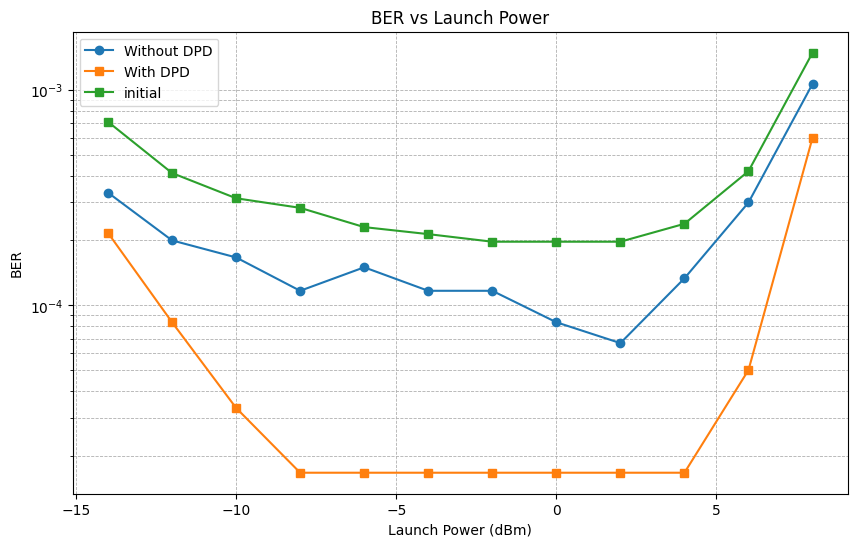

In [34]:
ber_nodpd = [r["BER"] for r in results_nodpd]
ber_dpd   = [r["BER"] for r in results_dpd]

plt.figure(figsize=(10, 6))

plt.semilogy(P_launch_dbm_list, ber_nodpd, 'o-', label='Without DPD')
plt.semilogy(P_launch_dbm_list, ber_dpd, 's-', label='With DPD')
plt.semilogy(P_launch_dbm_list, ber_list, 's-', label='initial')

plt.xlabel("Launch Power (dBm)")
plt.ylabel("BER")
plt.title("BER vs Launch Power")
plt.grid(True, which='both', linestyle='--', linewidth=0.6)
plt.legend()

In [17]:
print("\n==================== W/O DPD Results ====================\n")
for r in results_nodpd:
    print(f"DA={r['Data_Aided']}, CPR={r['CPR']}: "
          f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
          f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")
    
print("\n==================== W/ DPD Results ====================\n")
for r in results_dpd:
    print(f"DA={r['Data_Aided']}, CPR={r['CPR']}: "
          f"BER={r['BER']:.2e}, SER={r['SER']:.2e}, "
          f"SNR={r['SNR']:.2f} dB, EVM={r['EVM']*100:.1f} %, Q={r['Qfactor']:.2f}")


==================== W/O DPD Results ====================

DA=True, CPR=bps: BER=3.83e-04, SER=1.53e-03, SNR=17.77 dB, EVM=1.7 %, Q=5.27
DA=True, CPR=bps: BER=2.67e-04, SER=1.07e-03, SNR=18.40 dB, EVM=1.4 %, Q=5.40
DA=True, CPR=bps: BER=1.83e-04, SER=7.33e-04, SNR=18.86 dB, EVM=1.3 %, Q=5.52
DA=True, CPR=bps: BER=1.50e-04, SER=6.00e-04, SNR=19.18 dB, EVM=1.2 %, Q=5.58
DA=True, CPR=bps: BER=1.33e-04, SER=5.33e-04, SNR=19.39 dB, EVM=1.2 %, Q=5.62
DA=True, CPR=bps: BER=1.17e-04, SER=4.67e-04, SNR=19.51 dB, EVM=1.1 %, Q=5.66
DA=True, CPR=bps: BER=1.17e-04, SER=4.67e-04, SNR=19.57 dB, EVM=1.1 %, Q=5.66
DA=True, CPR=bps: BER=1.00e-04, SER=4.00e-04, SNR=19.62 dB, EVM=1.1 %, Q=5.70
DA=True, CPR=bps: BER=6.67e-05, SER=2.67e-04, SNR=19.57 dB, EVM=1.1 %, Q=5.82
DA=True, CPR=bps: BER=1.00e-04, SER=4.00e-04, SNR=19.40 dB, EVM=1.2 %, Q=5.70
DA=True, CPR=bps: BER=3.00e-04, SER=1.20e-03, SNR=18.90 dB, EVM=1.3 %, Q=5.35
DA=True, CPR=bps: BER=1.02e-03, SER=4.07e-03, SNR=17.81 dB, EVM=1.7 %, Q=4.89

===